# Лахин Никита Сергеевич ИУ5-65Б Вариант 9

Задача №2.
Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

In [371]:
from miceforest import ImputationKernel
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt


In [372]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


В рамках данной лабораторной работы, учитывая отсутствие категориальных признаков в исходном наборе данных, было принято решение о создании таких признаков посредством применения метода кластеризации.



In [373]:
# 1. KMeans - создание модели кластеризации
kmeans = KMeans(n_clusters=3, random_state=42)  # n_clusters - количество кластеров, random_state - для воспроизводимости

# 2. fit_predict - обучение модели и предсказание кластеров
df['cluster'] = kmeans.fit_predict(df)  # добавляем новый категориальный признак 'cluster' в DataFrame

# 3. Выводим первые несколько строк с новым признаком
print(df.head())  # проверяем результат


# 1. unique - получение уникальных значений
unique_clusters = df['cluster'].unique()  # получаем уникальные значения кластеров

# 2. value_counts - подсчет количества каждого уникального значения
cluster_counts = df['cluster'].value_counts()  # подсчитываем количество элементов в каждом кластере

# 3. Выводим результаты
print("Уникальные значения кластеров:", unique_clusters)  # выводим уникальные значения
print("Количество элементов в каждом кластере:\n", cluster_counts)  # выводим количество элементов


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   cluster  
0        1  
1        1  
2        1  
3        1  
4        1  
Уникальные значения кластеров: [1 0 2]
Количество элементов в каждом кластере:
 cluster
2    61
1    50
0    39
Name: count, dtype: int64


Удалю 20% процентов данных из 1 категориального и числового признака для выполнения задания

In [374]:


# 1. sample - случайный выбор индексов для удаления
indices_to_remove = df.sample(frac=0.2, random_state=42).index  # frac - доля данных для удаления, random_state - для воспроизводимости

# 2. loc - доступ к данным по индексу
df_updated = df.copy()  # создаем копию исходного DataFrame
df_updated.loc[indices_to_remove, ['petal width (cm)', 'cluster']] = np.nan  # заменяем значения на NaN в выбранных строках и колонках

# 3. Выводим результат
print(df_updated.head())  # проверяем результат


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   cluster  
0      1.0  
1      1.0  
2      1.0  
3      1.0  
4      1.0  


In [375]:
# 1. isnull - проверка на наличие NaN
null_columns = df_updated.isnull().sum()  # получаем количество NaN в каждой колонке

# 2. Выводим информацию о пустых колонках
print("Информация о пустых колонках:\n", null_columns[null_columns > 0])  # выводим только те колонки, где есть NaN

Информация о пустых колонках:
 petal width (cm)    30
cluster             30
dtype: int64


In [376]:
# Создаем ядро MICE
kernel = ImputationKernel(df_updated, num_datasets=1, random_state=42)

# Запускаем процесс импутации
kernel.mice(iterations=10, use_gbdt=False)

# Получаем восстановленные данные
df_updated = kernel.complete_data(dataset=0)

In [377]:
# 1. isnull - проверка на наличие NaN
null_columns = df_updated.isnull().sum()  # получаем количество NaN в каждой колонке

# 2. Выводим информацию о пустых колонках
print("Информация о пустых колонках:\n", null_columns[null_columns > 0])  # выводим только те колонки, где есть NaN

Информация о пустых колонках:
 Series([], dtype: int64)


              precision    recall  f1-score   support

           0       1.00      0.97      0.99        39
           1       0.98      1.00      0.99        50
           2       0.98      0.98      0.98        61

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



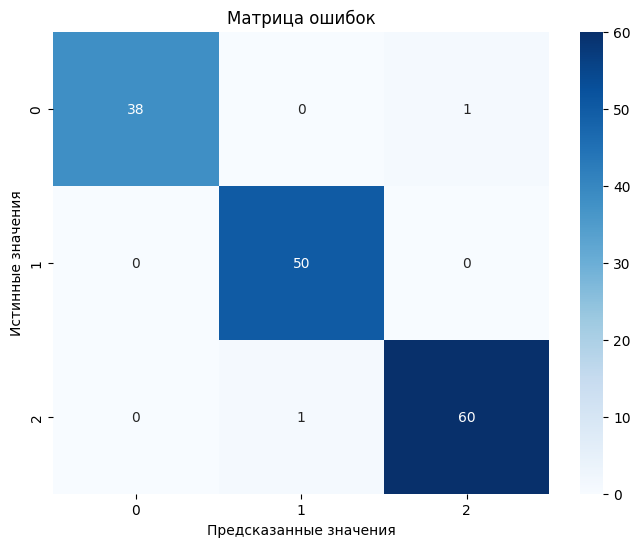

In [378]:
print(classification_report(df['cluster'], df_updated['cluster']))

conf_matrix = confusion_matrix(df['cluster'], df_updated['cluster'])

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')
plt.show()


In [379]:
mse = mean_squared_error(df['petal width (cm)'], df_updated['petal width (cm)'])  # вычисляем MSE для колонки 'petal width'
print("Средняя квадратичная ошибка для 'petal width':", mse)  # выводим MSE

Средняя квадратичная ошибка для 'petal width': 0.010333333333333332


Видим что метод MICE хорошо справился с задачей заполнения пропусков

Закодирую категориальные колонки с помощью метода one hot

In [380]:
df_updated['cluster'] = df_updated['cluster'].astype('category').astype('int')

df_one_hot = pd.get_dummies(df_updated['cluster'], prefix='cluster')

df_updated = pd.concat([df_updated, df_one_hot], axis=1)

df_updated.drop(columns=['cluster'], inplace=True)

In [381]:
df_updated.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster_0,cluster_1,cluster_2
0,5.1,3.5,1.4,0.2,False,True,False
1,4.9,3.0,1.4,0.2,False,True,False
2,4.7,3.2,1.3,0.2,False,True,False
3,4.6,3.1,1.5,0.2,False,True,False
4,5.0,3.6,1.4,0.2,False,True,False


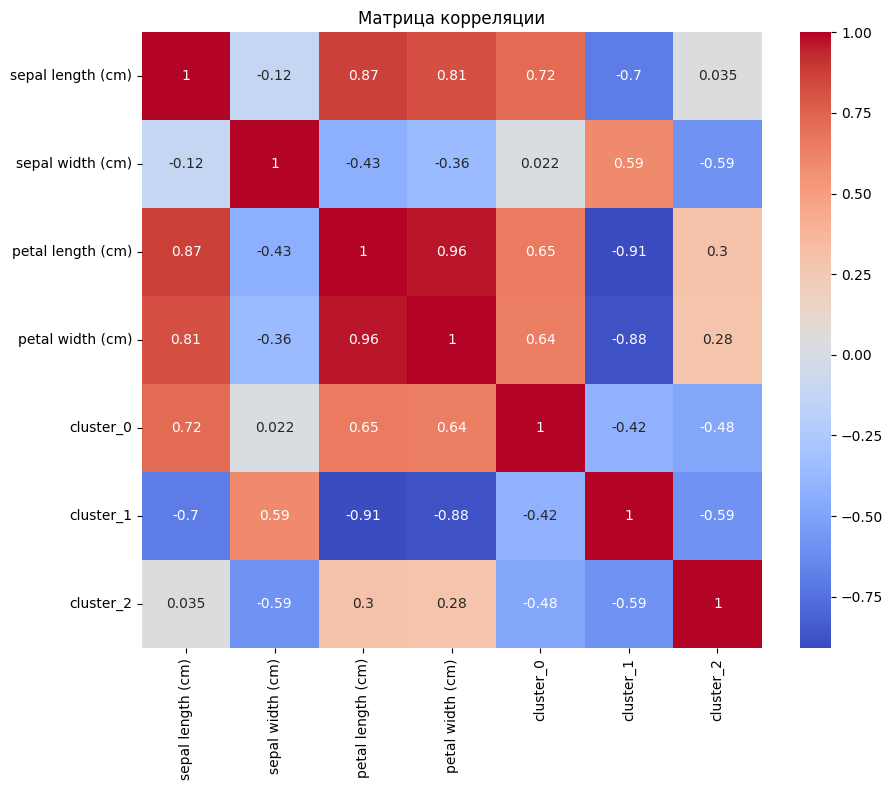

In [382]:
# 1. corr() - вычисление корреляции между колонками
correlation_matrix = df_updated.corr()  # создаем матрицу корреляции

# 2. Визуализируем матрицу корреляции
plt.figure(figsize=(10, 8))  # задаем размер фигуры
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')  # создаем тепловую карту
plt.title('Матрица корреляции')  # заголовок графика
plt.show()  # отображаем график


# Вывод
Для заполнения пропущенных значений я использовал метод MICE Forest, так как он обеспечивает высокую точность восстановления данных за счёт использования ансамбля деревьев и итеративного подхода.
Для построения моделей буду использовать те признаки, которые максимально коррелируют с целевой переменной, так как они наибольшей степени влияют на результат.
